In [1]:
# -----------------------------------------------------------------------------
# Atmospheric refraction in a spherically stratified atmosphere (shell model)
# Vectorized, notebook-style (no functions), with clear optics-oriented naming.
#
# Model:
# - Number-density profile (scaled):  ρ(z) = exp(-z/H)  with scale height H [km]
# - Refractive index:                 n(z) = 1 + κ · ρ(z)
# - Earth radius:                     R_earth [km]
# - Apparent altitude (above horizon) h' in degrees; cos(h') enters the integral.
#
# We compare:
# (A) Shell/integral model (cf. eq. like 3.202):  R(h') ≈ κ·cos(h') ∫_0^∞ I(x; h') dx
# (B) "Normal refraction" (Bennett-type) formula:  R(h') ≈ 1 / tan(h' + 7.31/(h'+4.4))
#
# Plots:
# 1) Density vs. height (semilog) and n(z) vs. height
# 2) Integrand behavior for zenith distances near 90° (h' near 0°)
# 3) Refraction R(h') in arcminutes: shell model (ISA-derived κ,H and Newton’s κ,H),
#    Bennett formula, and small-angle approximation at h' = 0
# -----------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.formatter.useoffset'] = False
# -----------------------------
# Constants (optics & geophysics)
# -----------------------------
kappa0   = 0.0003161               # κ at sea level (dimensionless)
n0       = 1.0 + kappa0            # refractive index at ground
R_earth  = 6366.0                  # Earth radius [km]

# -----------------------------
# ISA table (scaled density) to estimate H from last tabulated point

# We first determine H from data values:
# e.g., from https://github.com/sky-s/standard-atmosphere
# or https://web.archive.org/web/20170516220116/
# or http://home.anadolu.edu.tr/~mcavcar/common/ISAweb.pdf
# -----------------------------
rho_tab = np.array([10000, 9711, 9428, 9151, 8881, 8617, 8359, 8106,
                    7860, 7620, 7385, 7156, 6932, 6713, 6500, 6292], dtype=float)/10000.0
hn_kft  = np.linspace(0, 15, 16)       # "1000 ft" units
hn_km   = hn_kft / 3.28084             # convert "1000 ft" → "1000 m" ≈ km (x-axis label uses km)

# Scale height from the last tabulated point:  ρ = exp(-z/H) → H = -z / ln ρ
H0 = -hn_km[-1] / np.log(rho_tab[-1])  # [km], derived from ISA table
H  = H0                                 # default scale height
# Height grid for continuous profile display
z_km   = np.linspace(0.0, 50.0, 200)    # geometric height above ground [km]
rho_z  = np.exp(-z_km / H)              # scaled density
n_z    = 1.0 + kappa0 * rho_z           # refractive index profile


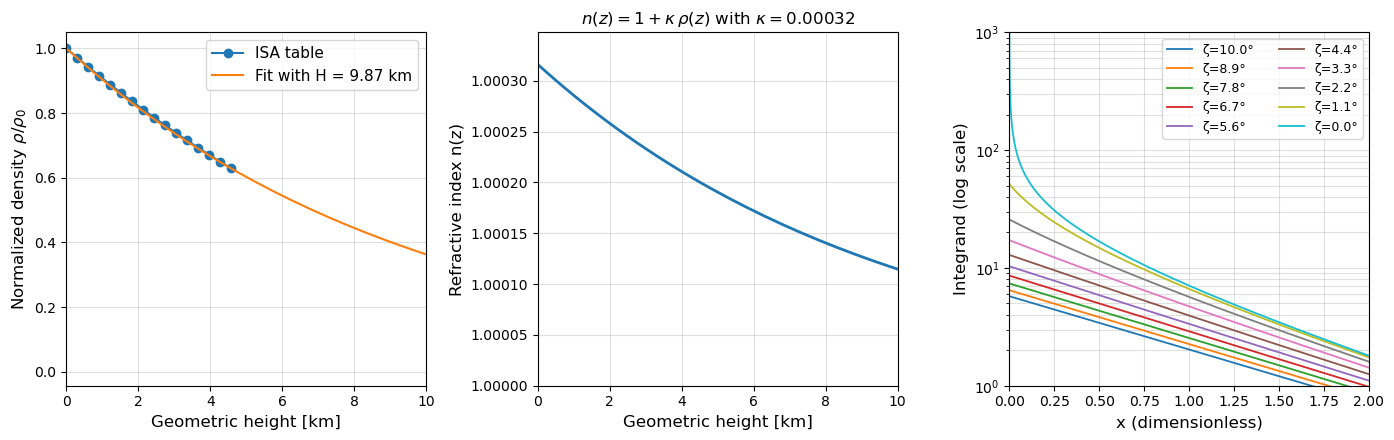

In [2]:
# -----------------------------
# Figure 1: Density & n(z)
# -----------------------------
plt.figure(figsize=(14, 4.5))

plt.subplot(1, 3, 1)
plt.plot(hn_km, rho_tab, 'o-', label='ISA table')
plt.plot(z_km,  rho_z,   '-',  label=f'Fit with H = {H0:4.2f} km')
plt.xlabel('Geometric height [km]', fontsize=12)
plt.ylabel(r'Normalized density $\rho/\rho_0$', fontsize=12)
plt.xlim(0, 10)
plt.grid(True, which='both', alpha=0.4)
plt.legend(fontsize=11)

plt.subplot(1, 3, 2)
plt.plot(z_km, n_z, lw=2)
plt.xlabel('Geometric height [km]', fontsize=12)
plt.ylabel('Refractive index n(z)', fontsize=12)
plt.xlim(0, 10)
plt.ylim(1, 1.0 + 1.1*kappa0)
plt.grid(True, alpha=0.4)
plt.title(rf'$n(z)=1+\kappa\,\rho(z)$ with $\kappa={kappa0:0.5f}$', fontsize=12)

# -----------------------------
# Figure 1 (right): Integrand check near horizon
# Zenith distance ζ ∈ [80°,90°], C = sin(ζ) = cos(h'), x ∈ [0, x_max]
# Integrand: exp(-x)/(1+κ e^{-x}) / sqrt( [((1+κ e^{-x})/(1+κ)) (1+H x / R)]^2 - C^2 )
# Vectorized over ζ and x.
# -----------------------------
N_zeta = 10
zeta_deg = np.linspace(80.0, 90.0, N_zeta)          # apparent zenith distance ζ [deg]
C = np.sin(np.deg2rad(zeta_deg))[:, None]            # shape (N_zeta, 1) = cos(h') since h' = 90°-ζ

x_max = 2.0
N_x   = 5000
x = np.linspace(0.0, x_max, N_x)[None, :]            # shape (1, N_x)

# Precompute x-dependent factors
exp_x   = np.exp(-x)
num_x   = exp_x / (1.0 + kappa0 * exp_x)             # numerator
geom_x  = ((1.0 + kappa0 * exp_x) / (1.0 + kappa0)) * (1.0 + (H * x) / R_earth)

# Denominator inside sqrt; clamp to avoid tiny negatives from FP errors
den2 = geom_x**2 - C**2                               # shape (N_zeta, N_x)
den  = np.sqrt(np.clip(den2, 1e-15, None))

integrand = num_x / den                               # (N_zeta, N_x)

plt.subplot(1, 3, 3)
for i in range(N_zeta):
    plt.semilogy(x.ravel(), integrand[i, :], lw=1.3, label=fr'ζ={(90 - zeta_deg[i]):.1f}°')
plt.xlabel('x (dimensionless)', fontsize=12)
plt.ylabel('Integrand (log scale)', fontsize=12)
plt.xlim(0, x_max)
plt.ylim(1e0, 1e3)
plt.grid(True, which='both', alpha=0.4)
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


# Atmospheric Refraction (Shell Model)
## Symbols
- $R$: Earth radius (km)  
- $H$: scale height (km)  
- $\kappa$: near-surface refractivity increment $n-1$ (dimensionless)  
- $h'$: apparent altitude above the horizon (degrees)  
- $\zeta$: apparent zenith distance (degrees), $\;\zeta = 90^\circ - h'$  
- $C$: direction cosine, $\;C=\sin\zeta=\cos h'$  
- $x$: dimensionless height, related to physical height by $z = H\,x$

---

## Vertical profiles
$$
\rho(z) \;=\; e^{-z/H}, \qquad
n(z) \;=\; 1 + \kappa\,\rho(z) \;=\; 1 + \kappa\,e^{-z/H}.
$$


## Shell–model geometry factors
Define
$$
e(x) \;=\; e^{-x}, \qquad
g(x) \;=\; \frac{1+\kappa\,e(x)}{1+\kappa}\;\Bigl(1+\frac{H}{R}\,x\Bigr).
$$

---

## Refraction integral (in radians)
With \(C=\cos h'\), the integrand is
$$
f(x;C,H,\kappa,R)
\;=\;
\frac{e^{-x}}{\,1+\kappa\,e^{-x}\,}\;
\frac{C}{\sqrt{\,g(x)^2 - C^{2}\,}} \, .
$$

Total refraction:
$$
R_{\text{shell}}(h') \;=\;
\kappa \int_{0}^{\infty} f(x;C,H,\kappa,R)\,dx .
$$

Conversion to arcminutes:
$$
R_{\text{arcmin}}(h') \;=\; 60\,\frac{180}{\pi}\;R_{\text{shell}}(h').
$$

---

## Small-altitude (near horizon) approximation
At \(h'\to 0\) (in radians):
$$
R(0) \;\approx\; \kappa \,\sqrt{\frac{\pi\,R}{2\,H}}.
$$

In arcminutes:
$$
R_{\text{arcmin}}(0) \;\approx\; 60\,\frac{180}{\pi}\;
\kappa \,\sqrt{\frac{\pi\,R}{2\,H}}.
$$

---

## Bennett-type “normal refraction” reference (degrees → arcmin)
For comparison, with \(h'\) in degrees:
$$
R_{\text{Bennett}}(h') \;=\;
\frac{1}{\tan\!\Bigl(h' + \dfrac{7.31}{\,h' + 4.4\,}\Bigr)}
\quad\text{[arcmin]}.
$$

---

## Practical notes (as implemented)
- The integral \(\int_0^{\infty}\) is evaluated numerically up to a large finite bound (e.g. \(x\approx 100\)).  
- To ensure numerical robustness near the square-root, use a small floor:
  \(\; \sqrt{\max(g(x)^2 - C^2,\,\epsilon)}\) with \(\epsilon \ll 1\).


In [3]:
def refraction_arcmin_for(kappa, H_km):
    """Vectorized shell-model refraction R(h') in arcminutes for given κ and H."""
    # x_int: shape (1, Nx) defined outside
    e = np.exp(-x_int)                                  # (1, Nx)
    num = e / (1.0 + kappa * e)                         # (1, Nx)
    g   = ((1.0 + kappa * e) / (1.0 + kappa)) * (1.0 + (H_km * x_int) / R_earth)  # (1, Nx)

    # Broadcast vs cos_h: cos_h is (Nh, 1), so g**2 will broadcast to (Nh, Nx)
    d2  = g**2 - cos_h**2                               # (Nh, Nx)
    d   = np.sqrt(np.clip(d2, 1e-15, None))             # (Nh, Nx)
    f   = num / d                                       # (Nh, Nx)

    # Integrate along x (axis=1); x must be 1D (Nx,)
    integ = np.trapz(f, x=x_int.ravel(), axis=1)        # (Nh,)

    # RefInt(h') [radians] = κ * cos(h') * \int f dx
    RefInt = kappa * cos_h.ravel() * integ              # (Nh,)

    # Convert to arcminutes
    return np.rad2deg(RefInt) * 60.0                    # (Nh,)

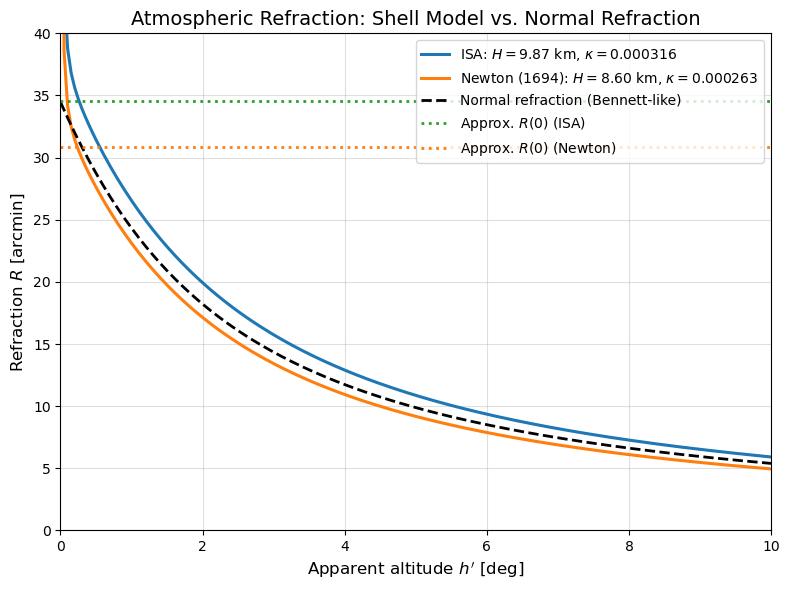

In [4]:
# -----------------------------
# Figure 2: Refraction vs apparent altitude h' (0°..10°)
# Compare:
#  - Integral shell model with two (κ,H) sets:
#      (a) ISA-derived (κ0,H0)
#      (b) Newton’s values (κN,HN)
#  - Bennett-like "normal refraction" formula:
#      R_Bennett(h') = 1 / tan( h' + 7.31 / (h' + 4.4) )  [arcmin]
# Also show small-angle approximation at h'=0:
#      R(0) ≈ κ * sqrt(π * R / (2H))  [radians]
# -----------------------------
h_ap_deg = np.linspace(0.0, 10.0, 200)                # apparent altitude h' [deg]
cos_h    = np.cos(np.deg2rad(h_ap_deg))[:, None]      # shape (Nh, 1)

# Bennett-type reference (already in arcminutes)
R_bennett_arcmin = 1.0 / np.tan(np.deg2rad(h_ap_deg + 7.31/(h_ap_deg + 4.4 + 1e-12)))

# x-grid for the refraction integral (0..~100 is plenty)
x_max_int = 100.0
Nx_int    = 6000
x_int     = np.linspace(0.0, x_max_int, Nx_int)[None, :]  # (1, Nx)



# Two parameter sets
kappa_ISA, H_ISA = kappa0, H0
kappa_New, H_New = 0.000263462, 8.59735

R_ISA_arcmin = refraction_arcmin_for(kappa_ISA, H_ISA)
R_New_arcmin = refraction_arcmin_for(kappa_New, H_New)

# h' = 0 small-angle approximation (constant w.r.t. h')
R0_ISA_arcmin = 60.0 * np.rad2deg(kappa_ISA * np.sqrt(np.pi * R_earth / (2.0 * H_ISA)))
R0_New_arcmin = 60.0 * np.rad2deg(kappa_New * np.sqrt(np.pi * R_earth / (2.0 * H_New)))

plt.figure(figsize=(8, 6))
plt.plot(h_ap_deg, R_ISA_arcmin, lw=2.2, label=fr'ISA: $H={H_ISA:4.2f}$ km, $\kappa={kappa_ISA:0.6f}$')
plt.plot(h_ap_deg, R_New_arcmin, lw=2.2, label=fr'Newton (1694): $H={H_New:4.2f}$ km, $\kappa={kappa_New:0.6f}$')
plt.plot(h_ap_deg, R_bennett_arcmin, 'k--', lw=2.0, label='Normal refraction (Bennett-like)')
plt.hlines(R0_ISA_arcmin, 0, 10, colors='tab:green', linestyles=':', lw=2.0,
           label=r'Approx. $R(0)$ (ISA)')
plt.hlines(R0_New_arcmin, 0, 10, colors='tab:orange', linestyles=':', lw=2.0,
           label=r'Approx. $R(0)$ (Newton)')

plt.xlabel(r"Apparent altitude $h'$ [deg]", fontsize=12)
plt.ylabel(r"Refraction $R$ [arcmin]", fontsize=12)
plt.xlim(0, 10)
plt.ylim(0, 40)
plt.grid(True, alpha=0.4)
plt.legend(fontsize=10, loc='upper right')
plt.title('Atmospheric Refraction: Shell Model vs. Normal Refraction', fontsize=14)
plt.tight_layout()
plt.show()
